In [1]:
import torch

def transform_to_tangent_space(data: torch.Tensor, epsilon: float = 1e-6) -> torch.Tensor:
    """
    Transforms unit vectors on a hypersphere to a tangent space 
    using the Riemannian Logarithmic Map.

    Args:
        data (torch.Tensor): Tensor of shape (N, D) containing N unit vectors.
                             Assumes rows are already normalized (||x||=1).
        epsilon (float): Threshold for numerical stability near 0 angles.

    Returns:
        torch.Tensor: Tensor of shape (N, D) in the tangent space (flat Euclidean).
    """
    # 1. Compute the Intrinsic Mean (mu)
    # We approximate the intrinsic mean by normalizing the Euclidean mean.
    # (For highly dispersed data, an iterative Karcher mean solver would be needed).
    mean_vector = data.mean(dim=0)
    mu = mean_vector / torch.norm(mean_vector)
    
    # 2. Compute Cosine Similarity and Clamp
    # Dot product of each point x_i with the mean mu
    cos_theta = torch.matmul(data, mu)
    
    # Clamp to [-1, 1] to prevent NaN in arccos due to floating point errors
    cos_theta = torch.clamp(cos_theta, -1.0 + epsilon, 1.0 - epsilon)
    
    # 3. Calculate Geodesic Distance (Theta)
    theta = torch.acos(cos_theta)
    
    # 4. Calculate the Scaling Factor (theta / sin(theta))
    # We must handle the case where theta is close to 0 (point is at the mean)
    # to avoid division by zero. Limit of x/sin(x) as x->0 is 1.
    sin_theta = torch.sin(theta)
    
    # Use torch.where to handle the singularity at 0
    scale_factor = torch.where(
        theta < epsilon, 
        torch.tensor(1.0, device=data.device, dtype=data.dtype), 
        theta / sin_theta
    )
    
    # 5. Apply the Log Map Formula: v = (theta/sin_theta) * (x - cos_theta * mu)
    # Reshape cos_theta and scale_factor to (N, 1) for broadcasting
    term_1 = data - (cos_theta.unsqueeze(1) * mu)
    tangent_vectors = scale_factor.unsqueeze(1) * term_1
    
    return tangent_vectors

In [2]:
import torch
from mini_trainer.hierarchical.integration import HierarchicalBuilder
from mini_trainer.classifier import last_layer_weights
from matplotlib import pyplot as plt

class_spec = HierarchicalBuilder.class_spec("/home/asger/Repositories/mini_trainer/examples/runs/ucloud_baseline/class_spec.json")
model, preproc = HierarchicalBuilder.build_model(
    weights="/home/asger/Repositories/mini_trainer/examples/runs/ucloud_baseline/weights/best.pt",
    model_type="efficientnet_v2_m",
    hidden=512,
    **class_spec
)
model.eval()
pass


In [3]:
from collections import Counter
family = [v[-1] for k, v in class_spec["labels"].items()]
families = sorted(set(family))
family2idx = {k : i for i, k in enumerate(families)}
familyidx = [family2idx[f] for f in family]
families_freq = Counter(family)
family_freq = [families_freq[f] for f in family]

In [4]:
llw = last_layer_weights(model).detach().clone()
llw /= llw.norm(2, 1, True)

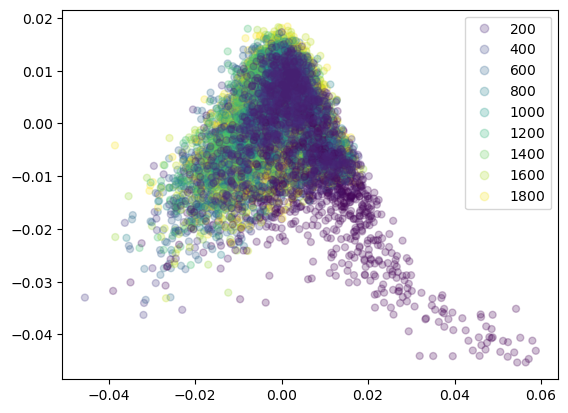

In [5]:
el = plt.scatter(*torch.pca_lowrank(llw, 2, True, 100)[0].T, c=family_freq, s=25, alpha=0.25)
plt.legend(*el.legend_elements())
plt.show()

In [ ]:
from estimate_voronoi_area import estimate_areas_ray_torch, RayExitConfig

pts = llw.clone().float().cuda()

areas = estimate_areas_ray_torch(
    pts,
    RayExitConfig(
        pilot=256,
        rel_se_target=0.01,
        n_min=128,
        n_max=50_000,
        seed=0,
        batch_pilot=16,
        batch_final=16,
        device="cuda" if torch.cuda.is_available() else "cpu",
        dtype=torch.float32,
        debug_cell=0,
        out_path="test_torch.jpeg",
        plot=False,
        max_competitors=256,  # set to e.g. 256 for a fast approximate mode
    )
)

/home/asger/micromamba/envs/mini_trainer/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


Pilot:   0%|          | 0/790 [00:00<?, ?it/s]

Final n=16296:   0%|          | 0/1 [00:00<?, ?it/s]

Final n=15268:   0%|          | 0/1 [00:00<?, ?it/s]

Final n=12919:   0%|          | 0/1 [00:00<?, ?it/s]

...

Final n=12867:   0%|          | 0/1 [00:00<?, ?it/s]

Final n=12973:   0%|          | 0/1 [00:00<?, ?it/s]

Final n=12563:   0%|          | 0/1 [00:00<?, ?it/s]

Final n=12993:   0%|          | 0/1 [00:00<?, ?it/s]

Final n=12688:   0%|          | 0/1 [00:00<?, ?it/s]

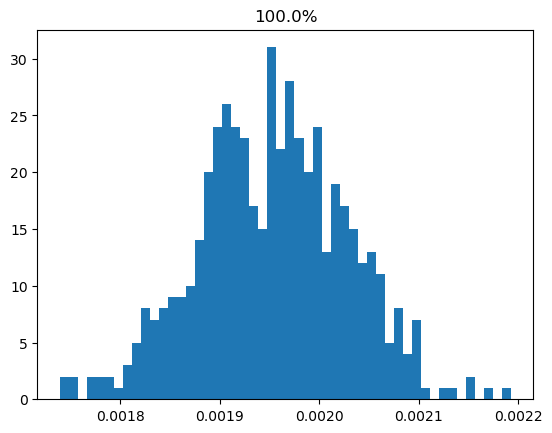

In [ ]:
plt.hist(areas["proportions"], 50)
plt.title(f'{areas["proportions"].sum().item():.1%}')
plt.show()

In [16]:
idx2cls = {v : k for k, v in class_spec["cls2idx"]["0"].items()}
result = []
for i, a in enumerate(areas["proportions"].tolist()):
    c = idx2cls[i]
    result.append((c, a))

with open("areas.csv", "w") as f:
    f.write("species,area")
    for c, a in result:
        f.write(f'\n{c},{a}')

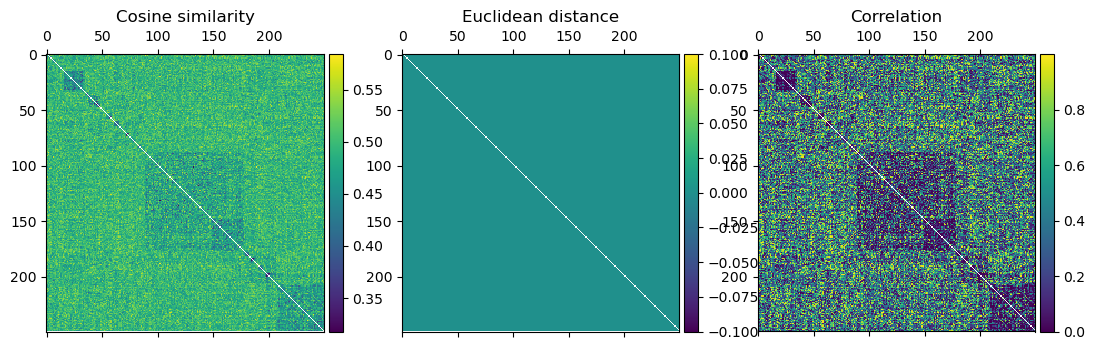

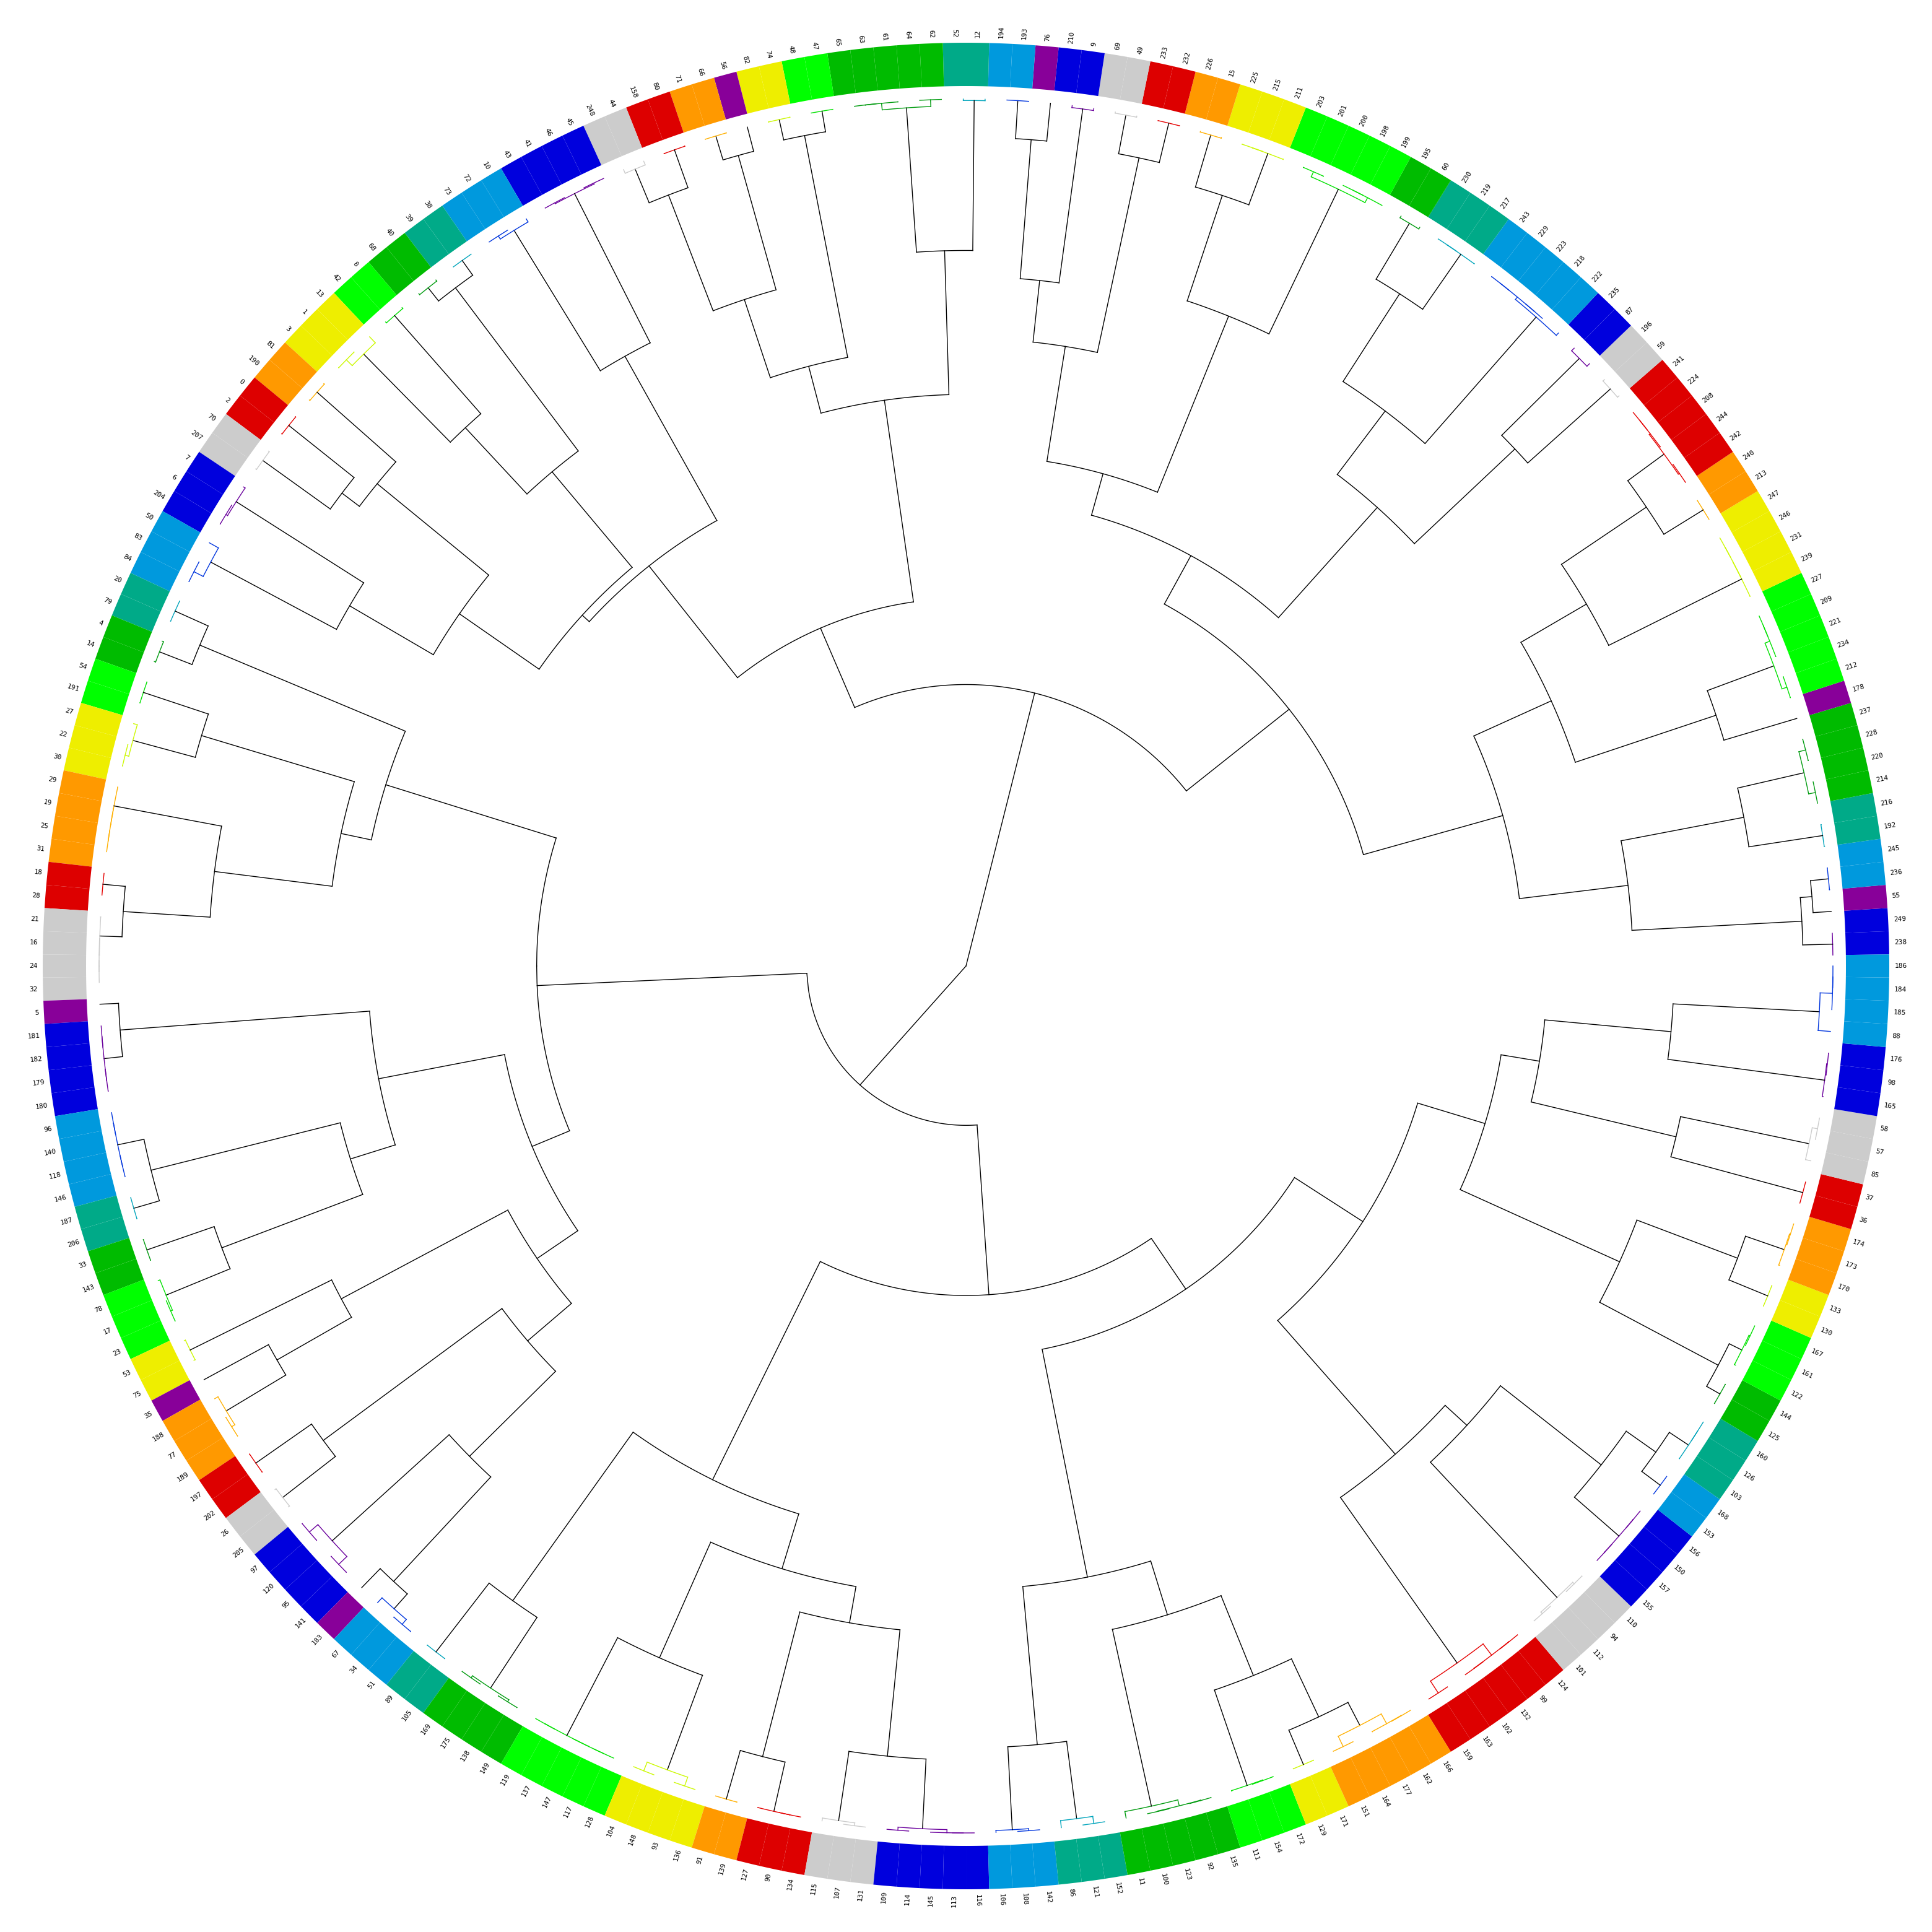

[238,
 249,
 55,
 236,
 245,
 192,
 216,
 214,
 220,
 228,
 237,
 178,
 212,
 234,
 221,
 209,
 227,
 239,
 231,
 246,
 247,
 213,
 240,
 242,
 244,
 208,
 224,
 241,
 59,
 196,
 87,
 235,
 222,
 218,
 223,
 229,
 243,
 217,
 219,
 230,
 60,
 195,
 199,
 198,
 200,
 201,
 203,
 211,
 215,
 225,
 15,
 226,
 232,
 233,
 49,
 69,
 9,
 210,
 76,
 193,
 194,
 12,
 52,
 62,
 64,
 61,
 63,
 65,
 47,
 48,
 74,
 82,
 56,
 66,
 71,
 80,
 158,
 44,
 248,
 45,
 46,
 41,
 43,
 10,
 72,
 73,
 38,
 39,
 40,
 68,
 8,
 42,
 13,
 1,
 3,
 81,
 190,
 0,
 2,
 70,
 207,
 7,
 6,
 204,
 50,
 83,
 84,
 20,
 79,
 4,
 14,
 54,
 191,
 27,
 22,
 30,
 29,
 19,
 25,
 31,
 18,
 28,
 21,
 16,
 24,
 32,
 5,
 181,
 182,
 179,
 180,
 96,
 140,
 118,
 146,
 187,
 206,
 33,
 143,
 78,
 17,
 23,
 53,
 75,
 35,
 188,
 77,
 189,
 197,
 202,
 26,
 205,
 97,
 120,
 95,
 141,
 183,
 67,
 34,
 51,
 89,
 105,
 169,
 175,
 138,
 149,
 119,
 137,
 147,
 117,
 128,
 104,
 148,
 93,
 136,
 91,
 139,
 127,
 90,
 134,
 115,
 107,
 131,


In [137]:
from plot_tree import hierarchical_cluster_llw

hierarchical_cluster_llw(llw[1000:1250], None)